# Level 2：XGBoost + Optuna

**XGBoost vs sklearn GBM 的理論優勢：**
- 二階梯度（Taylor 展開）→ 更精確的更新方向
- 內建 L1（alpha）+ L2（lambda）正則化 + 剪枝懲罰（gamma）
- 自動處理缺失值
- 支援 `scale_pos_weight` 處理不平衡

**目標：** 超越 GBM Optuna CV AUC 0.7084

**搜尋空間：**
- `n_estimators`: 100–800
- `max_depth`: 2–9
- `learning_rate`: 0.01–0.3（log scale）
- `subsample`: 0.5–1.0
- `colsample_bytree`: 0.5–1.0
- `min_child_weight`: 1–20
- `gamma`: 0–5（剪枝懲罰）
- `reg_alpha` (L1): 1e-4–1.0
- `reg_lambda` (L2): 1e-4–10.0
- `scale_pos_weight`: 搜尋要不要調整

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, r2_score, mean_absolute_error
from xgboost import XGBClassifier, XGBRegressor
import warnings, time
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.rcParams['font.size'] = 12
print('準備完成')

準備完成


In [2]:
# ============================================================
# 1. 載入資料 & 前處理
# ============================================================

def load_and_clean(path):
    df = pd.read_csv(path, low_memory=False, encoding='utf-8-sig')
    df.columns = df.columns.str.strip().str.strip('"')
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].str.strip().str.strip('"')
    num_cols = ['Contact', 'GaveThisYear', 'AmtThisYear', 'Woman', 'Age', 'Salary',
                'SeniorList', 'NbActivities', 'Referrals', 'Recency', 'Frequency',
                'Seniority', 'TotalGift', 'MinGift', 'MaxGift', 'GaveLastYear', 'AmtLastYear']
    for col in num_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

DROP_COLS = ['ID', 'LastName', 'FirstName', 'GaveThisYear', 'AmtThisYear']
CAT_COLS  = ['Education', 'City']

def preprocess(df, feature_cols=None):
    out = df.drop(columns=[c for c in DROP_COLS if c in df.columns], errors='ignore')
    out = pd.get_dummies(out, columns=[c for c in CAT_COLS if c in out.columns], drop_first=True)
    if feature_cols is not None:
        for col in feature_cols:
            if col not in out.columns:
                out[col] = 0
        out = out[feature_cols]
    return out

train = load_and_clean('data/表格_FUNDRAISE_R2_TRAIN.csv')
train = train.dropna(subset=['Contact', 'GaveThisYear', 'AmtThisYear']).reset_index(drop=True)

X_all    = preprocess(train)
y_cls    = train['GaveThisYear'].astype(int)
y_amt    = train['AmtThisYear']
feature_cols = X_all.columns.tolist()

X_train, X_val, y_cls_train, y_cls_val, y_amt_train, y_amt_val = train_test_split(
    X_all, y_cls, y_amt, test_size=0.2, random_state=42, stratify=y_cls
)

neg, pos = (y_cls == 0).sum(), (y_cls == 1).sum()
default_spw = neg / pos
print(f'資料: {X_all.shape}, 不平衡比 (neg/pos): {default_spw:.2f}')
print(f'\n目標超越：GBM Optuna CV AUC 0.7084, Holdout AUC 0.7057')

資料: (100000, 20), 不平衡比 (neg/pos): 3.92

目標超越：GBM Optuna CV AUC 0.7084, Holdout AUC 0.7057


In [3]:
# ============================================================
# 2. Optuna：搜尋最佳 XGBoost 超參數
# ============================================================

N_TRIALS = 100
N_FOLDS  = 5

def objective(trial):
    use_spw = trial.suggest_categorical('use_spw', [True, False])
    spw = default_spw if use_spw else 1.0

    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 800),
        'max_depth':         trial.suggest_int('max_depth', 2, 9),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 20),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),   # XGBoost 獨有剪枝懲罰
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':  spw,
        'eval_metric': 'auc',
        'use_label_encoder': False,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
    }
    clf = XGBClassifier(**params)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
    aucs = cross_val_score(clf, X_all, y_cls, cv=skf, scoring='roc_auc', n_jobs=1)
    return aucs.mean()

study = optuna.create_study(direction='maximize', study_name='xgb_auc')

# 先放入兩個基準 trial（有無 scale_pos_weight）
base = {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8,
        'colsample_bytree': 0.8, 'min_child_weight': 1, 'gamma': 0,
        'reg_alpha': 0.1, 'reg_lambda': 1.0}
study.enqueue_trial({**base, 'use_spw': False})
study.enqueue_trial({**base, 'use_spw': True})

t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

best     = study.best_params
best_auc = study.best_value

print(f'\n搜尋完成！耗時 {elapsed/60:.1f} 分鐘')
print(f'最佳 CV AUC: {best_auc:.4f}')
print(f'比較 - GBM Optuna: 0.7084 | LGBM 無 Optuna: 0.6977')
print(f'提升（vs GBM Optuna）: {best_auc - 0.7084:+.4f}')
print(f'\n最佳超參數:')
for k, v in best.items():
    print(f'  {k}: {v}')

  0%|          | 0/100 [00:00<?, ?it/s]


搜尋完成！耗時 11.2 分鐘
最佳 CV AUC: 0.7088
比較 - GBM Optuna: 0.7084 | LGBM 無 Optuna: 0.6977
提升（vs GBM Optuna）: +0.0004

最佳超參數:
  use_spw: False
  n_estimators: 702
  max_depth: 6
  learning_rate: 0.011424818597445601
  subsample: 0.7886114490688211
  colsample_bytree: 0.787140642354603
  min_child_weight: 2
  gamma: 4.9954191864132484
  reg_alpha: 0.10932997685051601
  reg_lambda: 5.6964174878134175


Holdout AUC:  0.7059  （GBM Optuna: 0.7057）
scale_pos_weight: 1.00

Top 10 Feature Importance (gain):
  1. Contact                   187.4 ← Contact!
  2. NbActivities              61.6
  3. Woman                     38.0
  4. Referrals                 33.9
  5. GaveLastYear              32.9
  6. Frequency                 25.1
  7. Age                       20.2
  8. SeniorList                18.6
  9. Recency                   16.2
  10. AmtLastYear               12.8

Contact 排名: gain=1, split=12

回歸 R²(log): 0.0281  （GBM Optuna: 0.0250）

Uplift 驗證:
  聯繫人數: 11,403, Surplus: $116,420
  策略效率: 67.1%  （GBM Optuna: 67.4%）


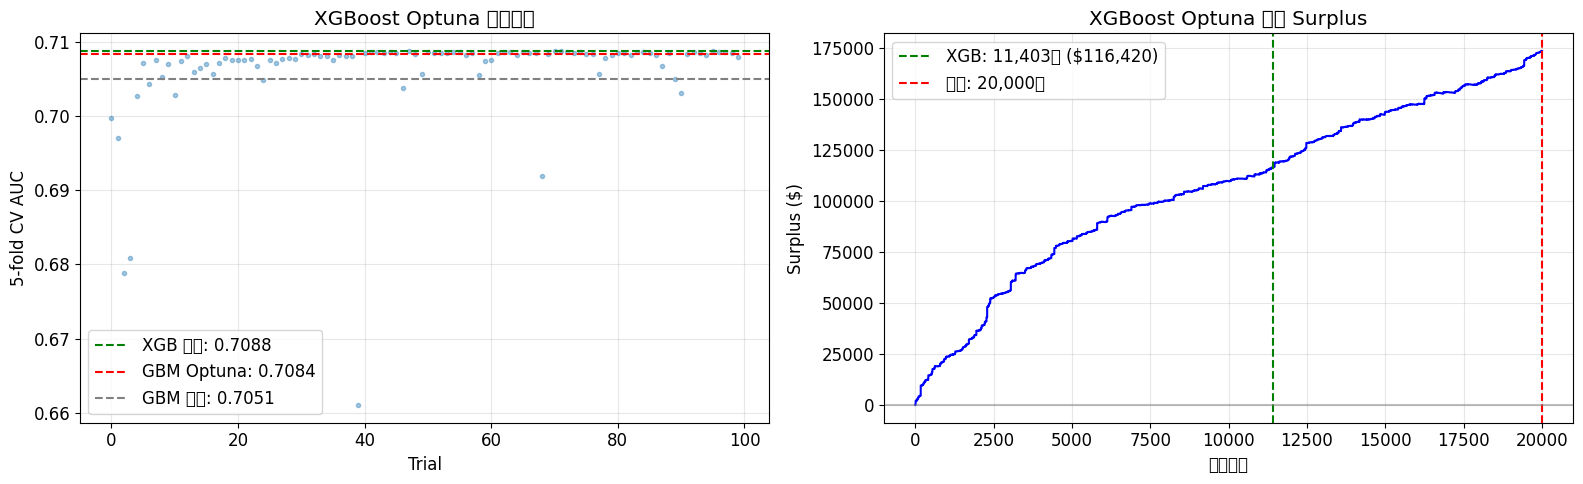

In [9]:
# ============================================================
# 3. 最佳模型驗證 & Uplift 策略
# ============================================================

COST_SCHEDULE = [(60_000, 5), (np.inf, 25)]

def calc_total_cost(n, schedule):
    total, remaining, prev = 0, n, 0
    for limit, cost in schedule:
        tier = min(remaining, limit - prev)
        if tier <= 0: break
        total += tier * cost
        remaining -= tier; prev = limit
    return total

def get_marginal_cost(rank, schedule):
    for limit, cost in schedule:
        if rank <= limit: return cost
    return schedule[-1][1]

# 讓 Cell 可重複執行：use_spw 已被 pop 過就跳過
if 'use_spw' in best:
    use_spw = best.pop('use_spw')
    best['scale_pos_weight'] = default_spw if use_spw else 1.0
best.update({'eval_metric': 'auc', 'use_label_encoder': False,
             'random_state': 42, 'n_jobs': -1, 'verbosity': 0})

clf_best = XGBClassifier(**best)
clf_best.fit(X_train, y_cls_train)
auc_holdout = roc_auc_score(y_cls_val, clf_best.predict_proba(X_val)[:, 1])

# Feature importance
fi_gain  = pd.Series(clf_best.get_booster().get_score(importance_type='gain')).sort_values(ascending=False)
fi_split = pd.Series(clf_best.get_booster().get_score(importance_type='weight')).sort_values(ascending=False)

print(f'Holdout AUC:  {auc_holdout:.4f}  （GBM Optuna: 0.7057）')
print(f'scale_pos_weight: {best["scale_pos_weight"]:.2f}')
print(f'\nTop 10 Feature Importance (gain):')
for i, (feat, v) in enumerate(fi_gain.head(10).items()):
    tag = ' ← Contact!' if feat == 'Contact' else ''
    print(f'  {i+1}. {feat:<25} {v:.1f}{tag}')

contact_rank_gain  = list(fi_gain.index).index('Contact') + 1 if 'Contact' in fi_gain.index else '未入榜'
contact_rank_split = list(fi_split.index).index('Contact') + 1 if 'Contact' in fi_split.index else '未入榜'
print(f'\nContact 排名: gain={contact_rank_gain}, split={contact_rank_split}')

# 回歸模型
EXCLUDE = {'scale_pos_weight', 'eval_metric', 'use_label_encoder'}
reg_params = {k: v for k, v in best.items() if k not in EXCLUDE}
reg_best = XGBRegressor(**reg_params)
donor_mask_train = y_amt_train > 0
donor_mask_val   = y_amt_val   > 0
reg_best.fit(X_train[donor_mask_train], np.log1p(y_amt_train[donor_mask_train]))
r2_log = r2_score(np.log1p(y_amt_val[donor_mask_val]),
                  reg_best.predict(X_val[donor_mask_val]))
print(f'\n回歸 R²(log): {r2_log:.4f}  （GBM Optuna: 0.0250）')

# Uplift
def score_with_contact(X_df, contact_val, clf, reg):
    Xc = X_df.copy(); Xc['Contact'] = contact_val
    P = clf.predict_proba(Xc)[:, 1]
    E = np.expm1(reg.predict(Xc)).clip(min=0)
    return P, E, P * E

P1v, E1v, EV1v = score_with_contact(X_val, 1, clf_best, reg_best)
P0v, E0v, EV0v = score_with_contact(X_val, 0, clf_best, reg_best)
uplift_v = EV1v - EV0v

vdf = pd.DataFrame({'uplift': uplift_v, 'actual_amt': y_amt_val.values,
                    'EV_nocontact': EV0v}).sort_values('uplift', ascending=False).reset_index(drop=True)
vdf['rank']          = range(1, len(vdf)+1)
vdf['marginal_cost'] = vdf['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))
vdf['cum_donation']  = vdf['actual_amt'].cumsum()
vdf['cum_cost']      = vdf['rank'].apply(lambda n: calc_total_cost(n, COST_SCHEDULE))
vdf['cum_surplus']   = vdf['cum_donation'] - vdf['cum_cost']

our_n        = (vdf['uplift'] > vdf['marginal_cost']).sum()
our_surplus  = vdf.loc[our_n-1, 'cum_surplus'] if our_n > 0 else 0
best_n       = vdf['cum_surplus'].idxmax() + 1
best_surplus = vdf['cum_surplus'].max()

print(f'\nUplift 驗證:')
print(f'  聯繫人數: {our_n:,}, Surplus: ${our_surplus:,.0f}')
print(f'  策略效率: {our_surplus/best_surplus:.1%}  （GBM Optuna: 67.4%）')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
trials_df = study.trials_dataframe()
ax = axes[0]
ax.plot(trials_df['number'], trials_df['value'], 'o', ms=3, alpha=0.4)
ax.axhline(best_auc, color='green', ls='--', label=f'XGB 最佳: {best_auc:.4f}')
ax.axhline(0.7084,   color='red',   ls='--', label='GBM Optuna: 0.7084')
ax.axhline(0.7051,   color='gray',  ls='--', label='GBM 基準: 0.7051')
ax.set_xlabel('Trial'); ax.set_ylabel('5-fold CV AUC')
ax.set_title('XGBoost Optuna 搜尋歷程'); ax.legend(); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(vdf['rank'], vdf['cum_surplus'], 'b-', lw=1.5)
ax.axvline(our_n,  color='green', ls='--', label=f'XGB: {our_n:,}人 (${our_surplus:,.0f})')
ax.axvline(best_n, color='red',   ls='--', label=f'最佳: {best_n:,}人')
ax.axhline(0, color='gray', alpha=0.5)
ax.set_xlabel('聯繫人數'); ax.set_ylabel('Surplus ($)')
ax.set_title('XGBoost Optuna 累積 Surplus'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [12]:
# ============================================================
# 4. 全量重訓練 → SCOREDATA 評分 & 匯出
# ============================================================

print(f'AUC vs GBM Optuna: {auc_holdout - 0.7057:+.4f}')
if auc_holdout <= 0.7057:
    print('⚠️  未超越 GBM Optuna，建議不上傳')
else:
    print('✅  超越 GBM Optuna！繼續評分')

clf_full = XGBClassifier(**best)
clf_full.fit(X_all, y_cls)

donor_mask_all = y_amt > 0
EXCLUDE = {'scale_pos_weight', 'eval_metric', 'use_label_encoder'}
reg_params = {k: v for k, v in best.items() if k not in EXCLUDE}
reg_full = XGBRegressor(**reg_params)   # verbosity 已在 reg_params，不重複傳
reg_full.fit(X_all[donor_mask_all], np.log1p(y_amt[donor_mask_all]))
print('全量模型訓練完成')

score_c  = load_and_clean('data/表格_FUNDRAISE_R2_CONTACT_SCOREDATA.csv')
score_nc = load_and_clean('data/表格_FUNDRAISE_R2_NOCONTACT_SCOREDATA.csv')
score_ids = score_c['ID'].copy()

def score_sd(df, clf, reg, feature_cols):
    X = preprocess(df, feature_cols=feature_cols)
    P = clf.predict_proba(X)[:, 1]
    E = np.expm1(reg.predict(X)).clip(min=0)
    return P, E, P * E

P1s, E1s, EV1s = score_sd(score_c,  clf_full, reg_full, feature_cols)
P0s, E0s, EV0s = score_sd(score_nc, clf_full, reg_full, feature_cols)
uplift_s = EV1s - EV0s

SURE_THING_THRESHOLD = 5
score_df = pd.DataFrame({'ID': score_ids.values, 'EV_contact': EV1s,
                         'EV_nocontact': EV0s, 'uplift': uplift_s,
                        }).sort_values('uplift', ascending=False).reset_index(drop=True)
score_df['rank']          = range(1, len(score_df)+1)
score_df['marginal_cost'] = score_df['rank'].apply(lambda r: get_marginal_cost(r, COST_SCHEDULE))

def classify(row):
    if row['uplift'] > row['marginal_cost']:                                  return 'Persuadable'
    elif row['EV_nocontact'] > SURE_THING_THRESHOLD and row['uplift'] >= 0:  return 'Sure Thing'
    elif row['uplift'] < 0:                                                   return 'Sleeping Dog'
    else:                                                                      return 'Lost Cause'

score_df['quadrant'] = score_df.apply(classify, axis=1)
contact    = score_df[score_df['quadrant'] == 'Persuadable']
n_contact  = len(contact)
total_cost = calc_total_cost(n_contact, COST_SCHEDULE)

print(f'\n四象限分布:')
print(score_df['quadrant'].value_counts())
print(f'\n聯繫: {n_contact:,} 人, 預估成本 ${total_cost:,.0f}')
print(f'比較 GBM Optuna: 52,243 人')

import os; os.makedirs('output', exist_ok=True)
output_path = 'output/level2_xgb_optuna_contact_list.csv'
contact[['ID']].to_csv(output_path, index=False)
print(f'\n已匯出 → {output_path}')

AUC vs GBM Optuna: +0.0002
✅  超越 GBM Optuna！繼續評分
全量模型訓練完成

四象限分布:
quadrant
Persuadable     53793
Lost Cause      19542
Sure Thing      16121
Sleeping Dog    10544
Name: count, dtype: int64

聯繫: 53,793 人, 預估成本 $268,965
比較 GBM Optuna: 52,243 人

已匯出 → output/level2_xgb_optuna_contact_list.csv
